In [1]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import h5py
from utils import get_eval_stats

In [67]:
target_protein=None
test_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/"
summary_func = np.mean

In [68]:
#################################

drakes_df = pd.read_csv(test_dir + "drakes_test.csv")
pretrained_df = pd.read_csv(test_dir + "pretrained_test.csv")

drakes_eval_stats = get_eval_stats(drakes_df, target_protein=target_protein, summary_func=summary_func)
pre_eval_stats = get_eval_stats(pretrained_df, target_protein=target_protein, summary_func=summary_func)

drakes_ddg_align = drakes_eval_stats['ddg_align']
pre_ddg_align = pre_eval_stats['ddg_align']

#################################

bon10_df = pd.read_csv(test_dir + "pretrained_test_ddg_bon_N=10.csv")
bon50_df = pd.read_csv(test_dir + "pretrained_test_ddg_bon_N=50.csv")

bon10_eval_stats = get_eval_stats(bon10_df, target_protein=target_protein, summary_func=summary_func)
bon50_eval_stats = get_eval_stats(bon50_df, target_protein=target_protein, summary_func=summary_func)

bon10_ddg_align = bon10_eval_stats['ddg_align']
bon50_ddg_align = bon50_eval_stats['ddg_align']

#################################

spec5_df = pd.read_csv(test_dir + "target/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=5.csv")
spec10_df = pd.read_csv(test_dir + "target/" + "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10.csv")

spec5_eval_stats = get_eval_stats(spec5_df, target_protein=target_protein, summary_func=summary_func)
spec10_eval_stats = get_eval_stats(spec10_df, target_protein=target_protein, summary_func=summary_func)

spec5_ddg_align = spec5_eval_stats['ddg_align']
spec10_ddg_align = spec10_eval_stats['ddg_align']

#################################

spec5_bon10_df = pd.read_csv(test_dir + "target/" + "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=5.csv")
spec10_bon10_df = pd.read_csv(test_dir + "target/" + "pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10.csv")

spec5_bon10_eval_stats = get_eval_stats(spec5_bon10_df, target_protein=target_protein, summary_func=summary_func)
spec10_bon10_eval_stats = get_eval_stats(spec10_bon10_df, target_protein=target_protein, summary_func=summary_func)

spec5_bon10_ddg_align = spec5_bon10_eval_stats['ddg_align']
spec10_bon10_ddg_align = spec10_bon10_eval_stats['ddg_align']

#################################

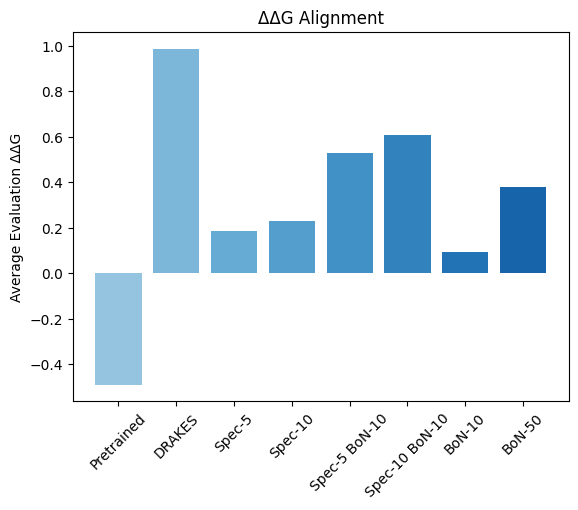

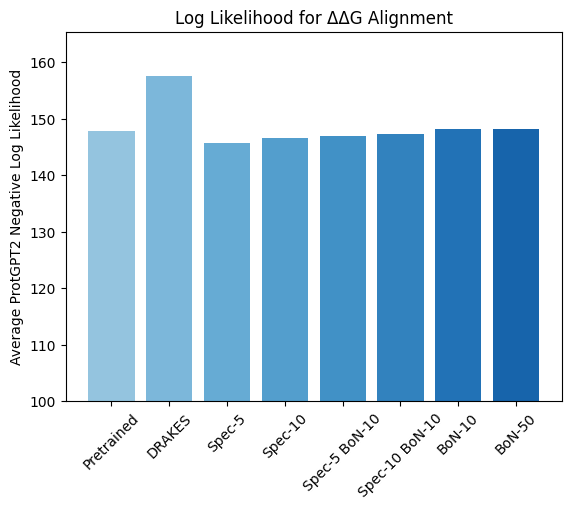

In [106]:
def display_stat_comp(stats, names, target_stat, ylabel, title, ylim=None, yscale=1):
    heights = [s[target_stat] * yscale for s in stats]

    cmap = plt.cm.Blues # type: ignore
    colors = cmap(np.linspace(0.4, 0.8, len(names)))

    plt.bar(names, heights, color=colors)

    plt.ylabel(ylabel)
    plt.title(title)

    if ylim is not None:
        plt.ylim(ylim)

    plt.xticks(rotation=45)
    plt.show()
stats = [pre_eval_stats, drakes_eval_stats, spec5_eval_stats, spec10_eval_stats, spec5_bon10_eval_stats, spec10_bon10_eval_stats, bon10_eval_stats, bon50_eval_stats]
names = ["Pretrained", "DRAKES", "Spec-5", "Spec-10", "Spec-5 BoN-10", "Spec-10 BoN-10", "BoN-10", "BoN-50"]

display_stat_comp(stats, names, "ddg", "Average Evaluation ΔΔG", "ΔΔG Alignment")
display_stat_comp(stats, names, "ll", "Average ProtGPT2 Negative Log Likelihood", "Log Likelihood for ΔΔG Alignment", yscale=-1, ylim=100)
# display_stat_comp(stats, names, "scrmsd", "scRMSD", "scRMSD for ΔΔG Alignment")
# display_stat_comp(stats, names, "success_rate", "Success Rate (%)", "Protein Success Comparison", ylim=(0,100), yscale=100)

In [70]:
# seq_recovery,seq,true_seq,protein_name,top_spec_interactions,spec_selections,spec_trajectory,r2_trajectory,loglikelihood,ddg,ddg_eval,scrmsd

In [84]:
def calc_avg_traj(df, traj_col, target_protein=None):
    if target_protein is not None:
        df = df[df['protein_name'] == target_protein + ".pdb"]
    
    trajectories = np.array([eval(lst) for lst in df[traj_col].tolist()])
    avg_traj = np.average(trajectories, axis=0)
    return avg_traj

def display_traj(df_lst, names, traj_col, ylabel, colors=None, target_protein=None, ylim=None, title="Protein Evaluation Trajectory"):
    trajectories = []
    for df in df_lst:
        avg_traj = calc_avg_traj(df, traj_col, target_protein=target_protein)
        trajectories.append(avg_traj)

    it_space = np.arange(trajectories[0].shape[0])

    if traj_col == "spec_trajectory":
        plt.axhline(drakes_ddg_align, color='limegreen', linestyle='--', label='DRAKES', linewidth=1)
        plt.axhline(pre_ddg_align, color='#3A98F2', linestyle='--', label='Pretrained', linewidth=1)
        plt.axhline(bon50_ddg_align, color='#483AF2', linestyle='--', label='BON50', linewidth=1)
        plt.axhline(bon10_ddg_align, color='#843AF2', linestyle='--', label='BON10', linewidth=1)

    for i, (traj, name) in enumerate(zip(trajectories, names)):
        if colors is not None:
            plt.plot(it_space, traj, label=name, color=colors[i % len(colors)])
        else:
            plt.plot(it_space, traj, label=name)

    plt.xlabel("Feedback Iterations")
    plt.ylabel(ylabel)
    protein_info = "" if target_protein is None else f": {target_protein}"
    plt.title(title+protein_info)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, frameon=False)
    plt.xlim(it_space[0], it_space[-1])
    if ylim is not None:
        plt.ylim(ylim)
    plt.show()

In [85]:
dfs = [spec5_df, spec10_df, spec5_bon10_df, spec10_bon10_df]
names = ['Spec-5', 'Spec-10', "Spec-5 BoN-10", "Spec-10 BoN-10"]
colors = ["#61F4DE","#3AD2F2", "#D68BF2", "#C03AF2"]

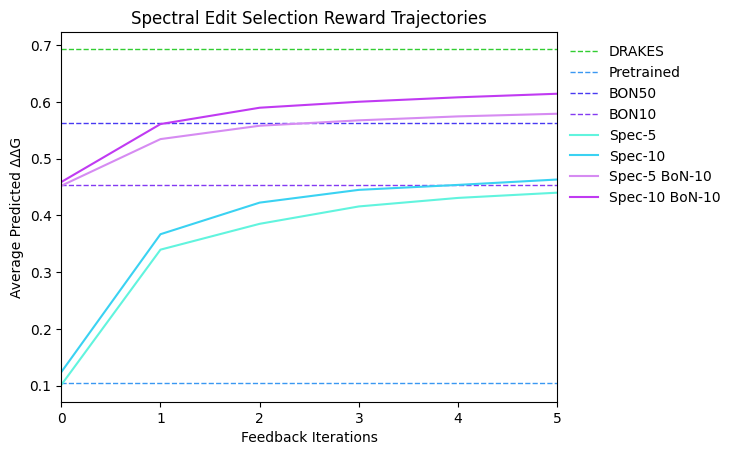

In [91]:
traj_col = 'spec_trajectory'
ylabel = "Average Predicted ΔΔG"
ylim = None
title = "Spectral Edit Selection Reward Trajectories"

display_traj(dfs, names, traj_col, ylabel, colors=colors, ylim=ylim, target_protein=target_protein, title=title)

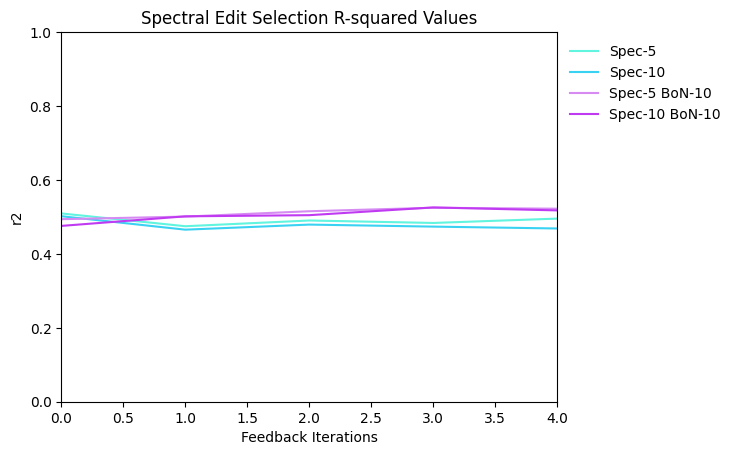

In [92]:
traj_col = 'r2_trajectory'
ylabel = "r2"
ylim = (0, 1)
title = "Spectral Edit Selection R-squared Values"

display_traj(dfs, names, traj_col, ylabel, colors=colors, ylim=ylim, target_protein=target_protein, title=title)

In [118]:
import random 

def evaluate_ddg_ll_corr_mult(df_list, labels, protein, title='', selected_samples=None, colors=None):
    for i, df in enumerate(df_list):
        if protein is not None:
            df = df[df['protein_name'] == protein + ".pdb"]
        pre_ddg = df['ddg_eval']
        pre_protgpt = df['loglikelihood']
        if selected_samples is not None and len(pre_ddg) > selected_samples: # type: ignore
            ids = random.sample(range(len(pre_ddg)), selected_samples) # type: ignore
            pre_ddg = np.array(pre_ddg)[ids]
            pre_protgpt = np.array(pre_protgpt)[ids]
        if colors is not None:
            plt.scatter(pre_ddg, pre_protgpt, label=labels[i], c=colors[i])
        else:
            plt.scatter(pre_ddg, pre_protgpt, label=labels[i])
    plt.xlabel('ΔΔG Eval')
    plt.ylabel('Log Likelihood')
    plt.title(title)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, frameon=False)
    plt.show()

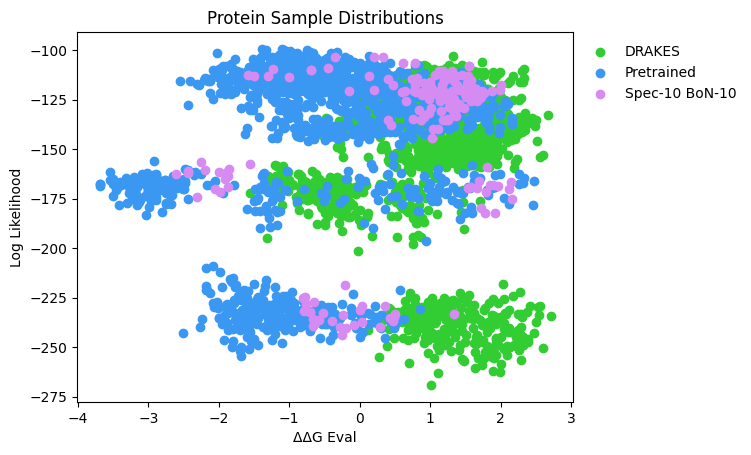

In [135]:
df_list = [drakes_df, pretrained_df, spec10_bon10_df]
labels = ["DRAKES", "Pretrained", "Spec-10 BoN-10"]
colors = ["limegreen", "#3A98F2", "#D68BF2"]
protein = None
title = f'{protein} Protein Sample Distribution' if protein is not None else "Protein Sample Distributions"
evaluate_ddg_ll_corr_mult(df_list, labels, protein, title=title, selected_samples=None, colors=colors)